# Chapter 04: Fundamental Theorems and Distribution Theory

Source span: printed pages 57-82; PDF pages 74-99. The source was used for chapter orientation, terminology, and concept order only. The prose, simulations, diagrams, code, and checks below are original course material.

## Chapter Question

How much of a circular distribution is visible through its integer Fourier coefficients, and when can circular statistics be replaced by planar or tangent normal approximations without losing the geometry?

This chapter has two recurring moves. First, a distribution on the circle is encoded by the sequence

$$\phi_p = E\{\exp(i p \Theta)\}, \quad p \in \mathbb{Z},$$

so convolution, wrapping, lattice behavior, and convergence become operations on a fingerprint of complex numbers. Second, sums of unit vectors turn angles into planar random walks. The resultant vector carries both a direction and a length, but those two coordinates behave differently at the origin, under uniformity, and under high concentration.

The notebook makes those moves visible. We inspect characteristic-function fingerprints, simulate uniform random-walk resultants, compare central-limit approximations in tangent coordinates, and test high-concentration chi-square approximations with numeric diagnostics.


## Computational Translation Guide

| Chapter idea | Computational object | What to inspect | Check used here |
| --- | --- | --- | --- |
| Circular characteristic function | Integer-indexed array of complex coefficients | Which harmonics survive and how phase rotates | conjugate symmetry and known model coefficients |
| Stable and lattice circular laws | Coefficients with exact unit-modulus spikes | Whether nonzero harmonics fail to decay | lattice multiples remain visible |
| Resultant distribution | Sum of unit vectors $(C,S)$ and length $R$ | Endpoint cloud and radial statistic | $E(\bar R^2) \approx 1/n$ under uniformity |
| Circular CLT | Planar CLT for $(\bar C,\bar S)$ plus tangent map | Local ellipse and standardized mean direction | empirical covariance near analytic covariance |
| High concentration | Small-angle normal model around the mean direction | Chi-square decomposition of angular scatter | KS distances and additive decomposition residual |

Library routing: `numpy` handles vectorized circular simulation, `scipy.special` supplies Bessel ratios for von Mises fingerprints and tangent variances, `scipy.stats` supplies normal and chi-square references, `matplotlib` saves durable static diagnostic diagrams, and `plotly` creates the applied lab HTML where approximation regimes can be toggled. Richer 3D, mesh, GIS, or topology libraries are not a better fit here because the chapter geometry is a circle embedded in the plane plus scalar distribution approximations.


## Source-Specific Visual Storyboard

1. Characteristic-function fingerprints: compare Fourier coefficients for uniform, lattice, cardioid, wrapped normal, and von Mises models. The learner should see that a distribution is identified by harmonic content, not by a line-based moment sequence.
2. Random-walk/resultant distributions: simulate unit-step walks and compare the resultant statistic with the Rayleigh/chi-square limit. The learner should see why the mean direction is uniform under isotropy while length remains informative.
3. CLT in tangent coordinates: sample from a nonuniform von Mises law, view the planar mean-vector CLT, and standardize the mean direction in the tangent line. The learner should see where the delta method is valid.
4. High-concentration approximations: simulate concentrated von Mises samples and split angular scatter into direction and concentration pieces. The learner should see the circular analogue of a normal sum-of-squares decomposition.
5. Applied lab: toggle simulation regimes and decide when an approximation is accurate enough for a planned sample size and concentration.


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        direct = candidate
        nested = candidate / "Directional-Statistics"
        for possible in (direct, nested):
            if (
                (possible / "AGENTS.md").exists()
                and (possible / "scripts" / "validate_dirstats_course.py").exists()
                and (possible / "utils").exists()
            ):
                return possible
    raise RuntimeError("Could not locate Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-04"
SOURCE_SPAN = {"printed_pages": "57-82", "pdf_pages": "74-99"}
print(f"Course root: {BOOK_ROOT}")
print(f"Artifact topic: {TOPIC}")
SOURCE_SPAN


Course root: D:\Geometry\Directional-Statistics
Artifact topic: chapter-04


{'printed_pages': '57-82', 'pdf_pages': '74-99'}

In [2]:
import json
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import special, stats

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts, read_json

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(20260404)
all_artifacts = []
chapter_checks = {}


def wrap_pi(theta):
    return (np.asarray(theta) + np.pi) % (2 * np.pi) - np.pi


def unit_components(theta):
    theta = np.asarray(theta)
    return np.cos(theta), np.sin(theta)


def resultant(theta, axis=-1):
    c = np.cos(theta).mean(axis=axis)
    s = np.sin(theta).mean(axis=axis)
    return c, s, np.hypot(c, s), np.arctan2(s, c)


def A1(kappa):
    return special.iv(1, kappa) / special.iv(0, kappa)


def Ap(order, kappa):
    return special.iv(order, kappa) / special.iv(0, kappa)


def ks_distance(samples, distribution):
    result = stats.kstest(np.asarray(samples), distribution.cdf)
    return float(result.statistic)


## Characteristic-Function Fingerprints

On the line, a characteristic function is sampled over a continuum of frequencies. On the circle, the natural frequencies are the integers. That discreteness is powerful: Fourier inversion and Parseval identities live on the same coefficient sequence, and convolution simply multiplies coefficients.

The figure below treats several familiar circular models as fingerprints. A uniform law has only the zero harmonic. A lattice law keeps exact spikes at multiples of the lattice size. A cardioid uses only the first harmonic. A wrapped normal damps high frequencies like a Gaussian in frequency space. A von Mises law damps through Bessel ratios.


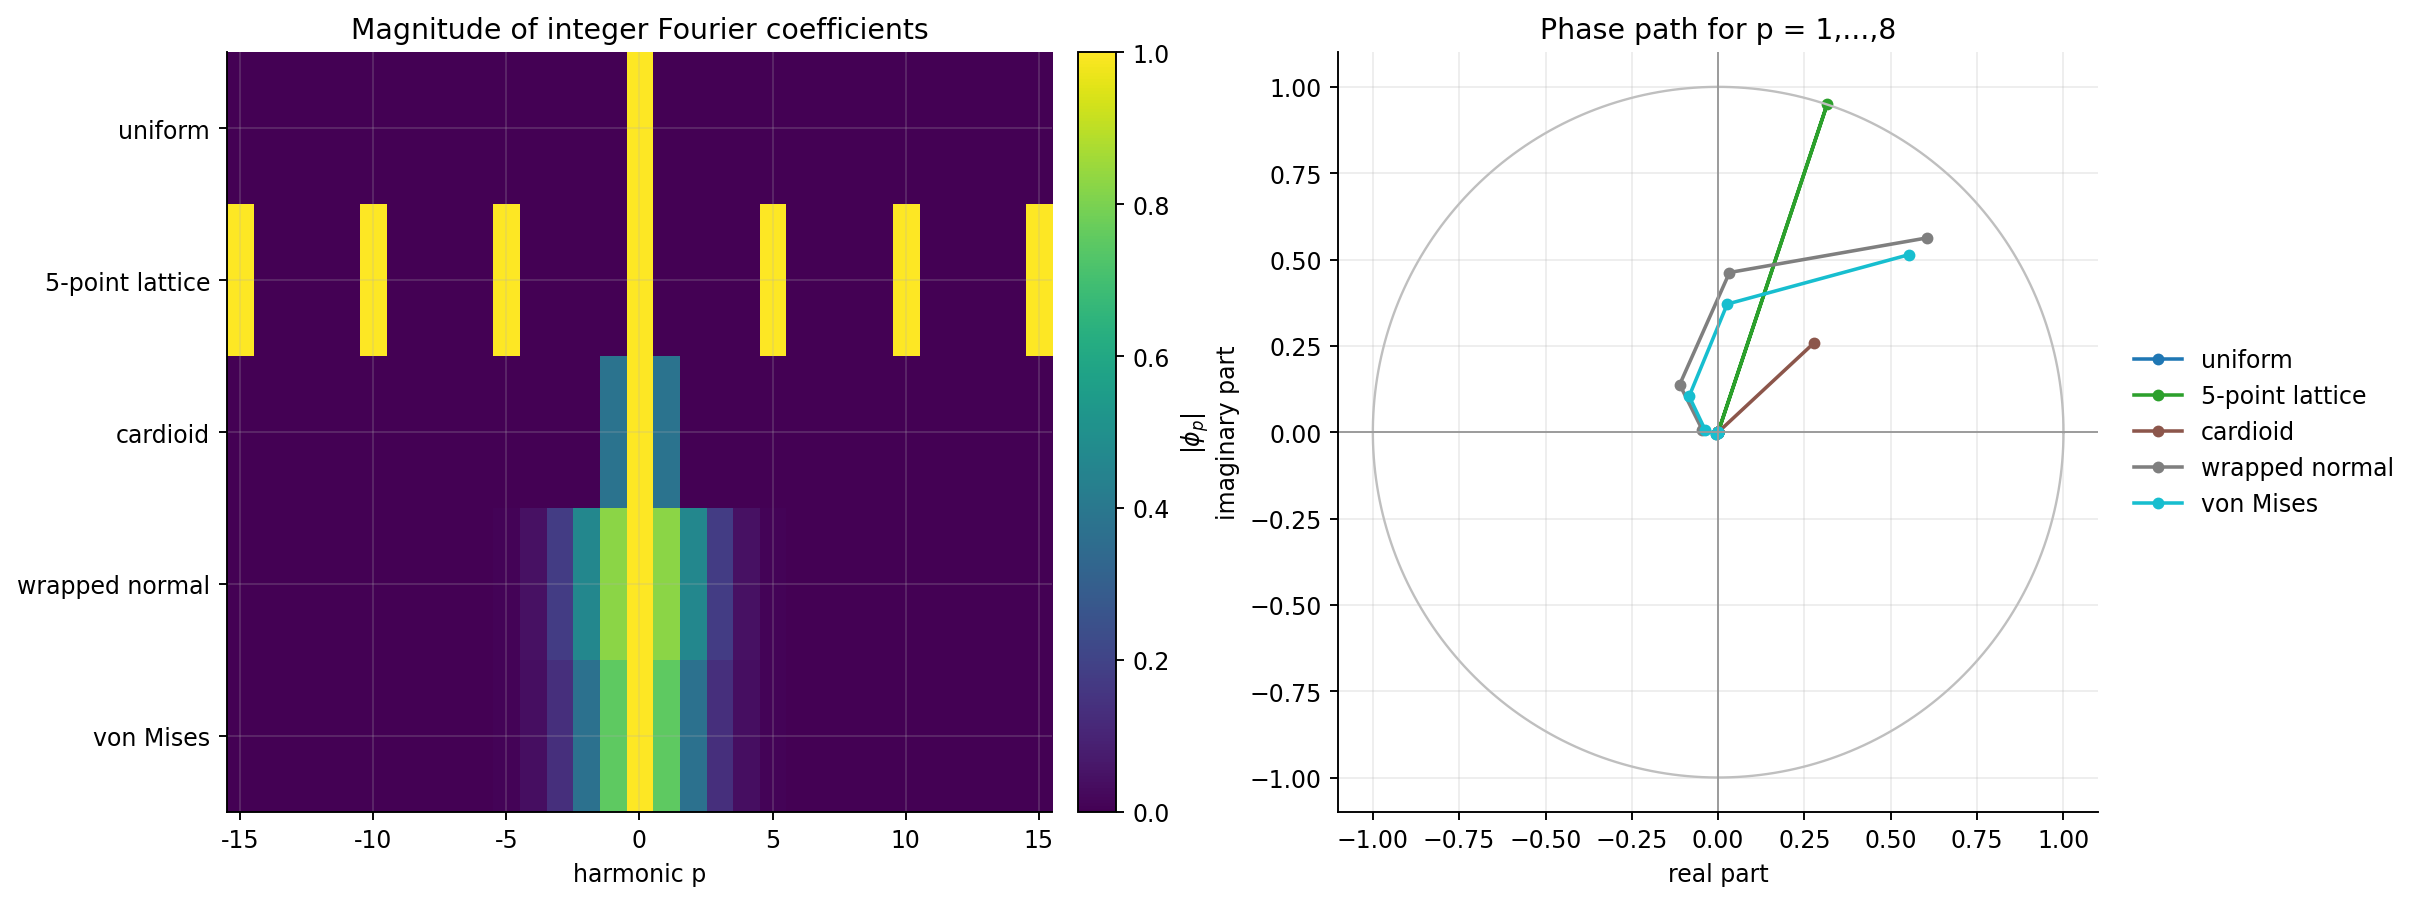

{'source_span': {'printed_pages': '57-82', 'pdf_pages': '74-99'},
 'max_conjugate_symmetry_error': 0.0,
 'uniform_nonzero_harmonic_max_abs': 0.0,
 'lattice_visible_harmonics': [-15, -10, -5, 5, 10, 15],
 'von_mises_first_ratio': 0.7536668999383394,
 'wrapped_normal_p10_abs': 4.4963494622808535e-09}

In [3]:
p_grid = np.arange(-15, 16)
p_pos = np.arange(0, 16)
mu = 0.75
models = {}
models["uniform"] = np.where(p_grid == 0, 1.0 + 0j, 0.0 + 0j)
models["5-point lattice"] = np.where(p_grid % 5 == 0, np.exp(1j * p_grid * 0.25), 0.0 + 0j)
models["cardioid"] = np.where(p_grid == 0, 1.0 + 0j, 0.0 + 0j)
models["cardioid"] = models["cardioid"].astype(complex)
models["cardioid"][p_grid == 1] = 0.38 * np.exp(1j * mu)
models["cardioid"][p_grid == -1] = 0.38 * np.exp(-1j * mu)
models["wrapped normal"] = np.exp(-0.5 * (0.62 ** 2) * p_grid ** 2) * np.exp(1j * p_grid * mu)
models["von Mises"] = np.array([special.iv(abs(int(p)), 2.4) / special.iv(0, 2.4) * np.exp(1j * p * mu) for p in p_grid])

magnitude = np.vstack([np.abs(v) for v in models.values()])
phase = np.angle(np.vstack([v for v in models.values()]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
im = axes[0].imshow(magnitude, aspect="auto", cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Magnitude of integer Fourier coefficients")
axes[0].set_xlabel("harmonic p")
axes[0].set_yticks(np.arange(len(models)))
axes[0].set_yticklabels(list(models))
axes[0].set_xticks(np.arange(0, len(p_grid), 5))
axes[0].set_xticklabels(p_grid[::5])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.03, label=r"$|\phi_p|$")

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
for (name, coeffs), color in zip(models.items(), colors):
    mask = (p_grid >= 1) & (p_grid <= 8)
    axes[1].plot(np.real(coeffs[mask]), np.imag(coeffs[mask]), "o-", lw=1.5, ms=4, color=color, label=name)
unit = np.exp(1j * np.linspace(0, 2 * np.pi, 300))
axes[1].plot(unit.real, unit.imag, color="0.75", lw=1)
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].axvline(0, color="0.6", lw=0.8)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Phase path for p = 1,...,8")
axes[1].set_xlabel("real part")
axes[1].set_ylabel("imaginary part")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fingerprint_path = save_matplotlib(fig, TOPIC, "characteristic-functions", "characteristic-function-fingerprints.png", dpi=170)
plt.close(fig)
all_artifacts.append(fingerprint_path)
display_artifact(fingerprint_path, width=980)

fingerprint_checks = {
    "source_span": SOURCE_SPAN,
    "max_conjugate_symmetry_error": float(max(
        np.max(np.abs(coeffs - np.conjugate(coeffs[::-1]))) for coeffs in models.values()
    )),
    "uniform_nonzero_harmonic_max_abs": float(np.max(np.abs(models["uniform"][p_grid != 0]))),
    "lattice_visible_harmonics": [int(p) for p, val in zip(p_grid, models["5-point lattice"]) if abs(val) > 0.999 and p != 0],
    "von_mises_first_ratio": float(abs(models["von Mises"][p_grid == 1][0])),
    "wrapped_normal_p10_abs": float(abs(models["wrapped normal"][p_grid == 10][0])),
}
chapter_checks["fingerprints"] = fingerprint_checks
fingerprint_json_path = save_json(fingerprint_checks, TOPIC, "checks", "characteristic-function-fingerprints.json")
all_artifacts.append(fingerprint_json_path)
fingerprint_checks


## Random Walks and Resultant Distributions

For independent uniform angles, the resultant vector is a unit-step random walk endpoint. Rotation invariance makes the mean direction uniform, but the length is not uniform. The length measures how much accidental alignment remains after adding the steps.

The statistic used in many large-sample uniform calculations is

$$T_n = 2n\bar R^2 = \frac{2R^2}{n},$$

where $R$ is the unscaled endpoint length and $\bar R = R/n$. Under uniformity, $T_n$ approaches a chi-square law with two degrees of freedom. The approximation is already readable in the histograms, while the two-step case keeps a visible exact boundary singularity at $R=2$.


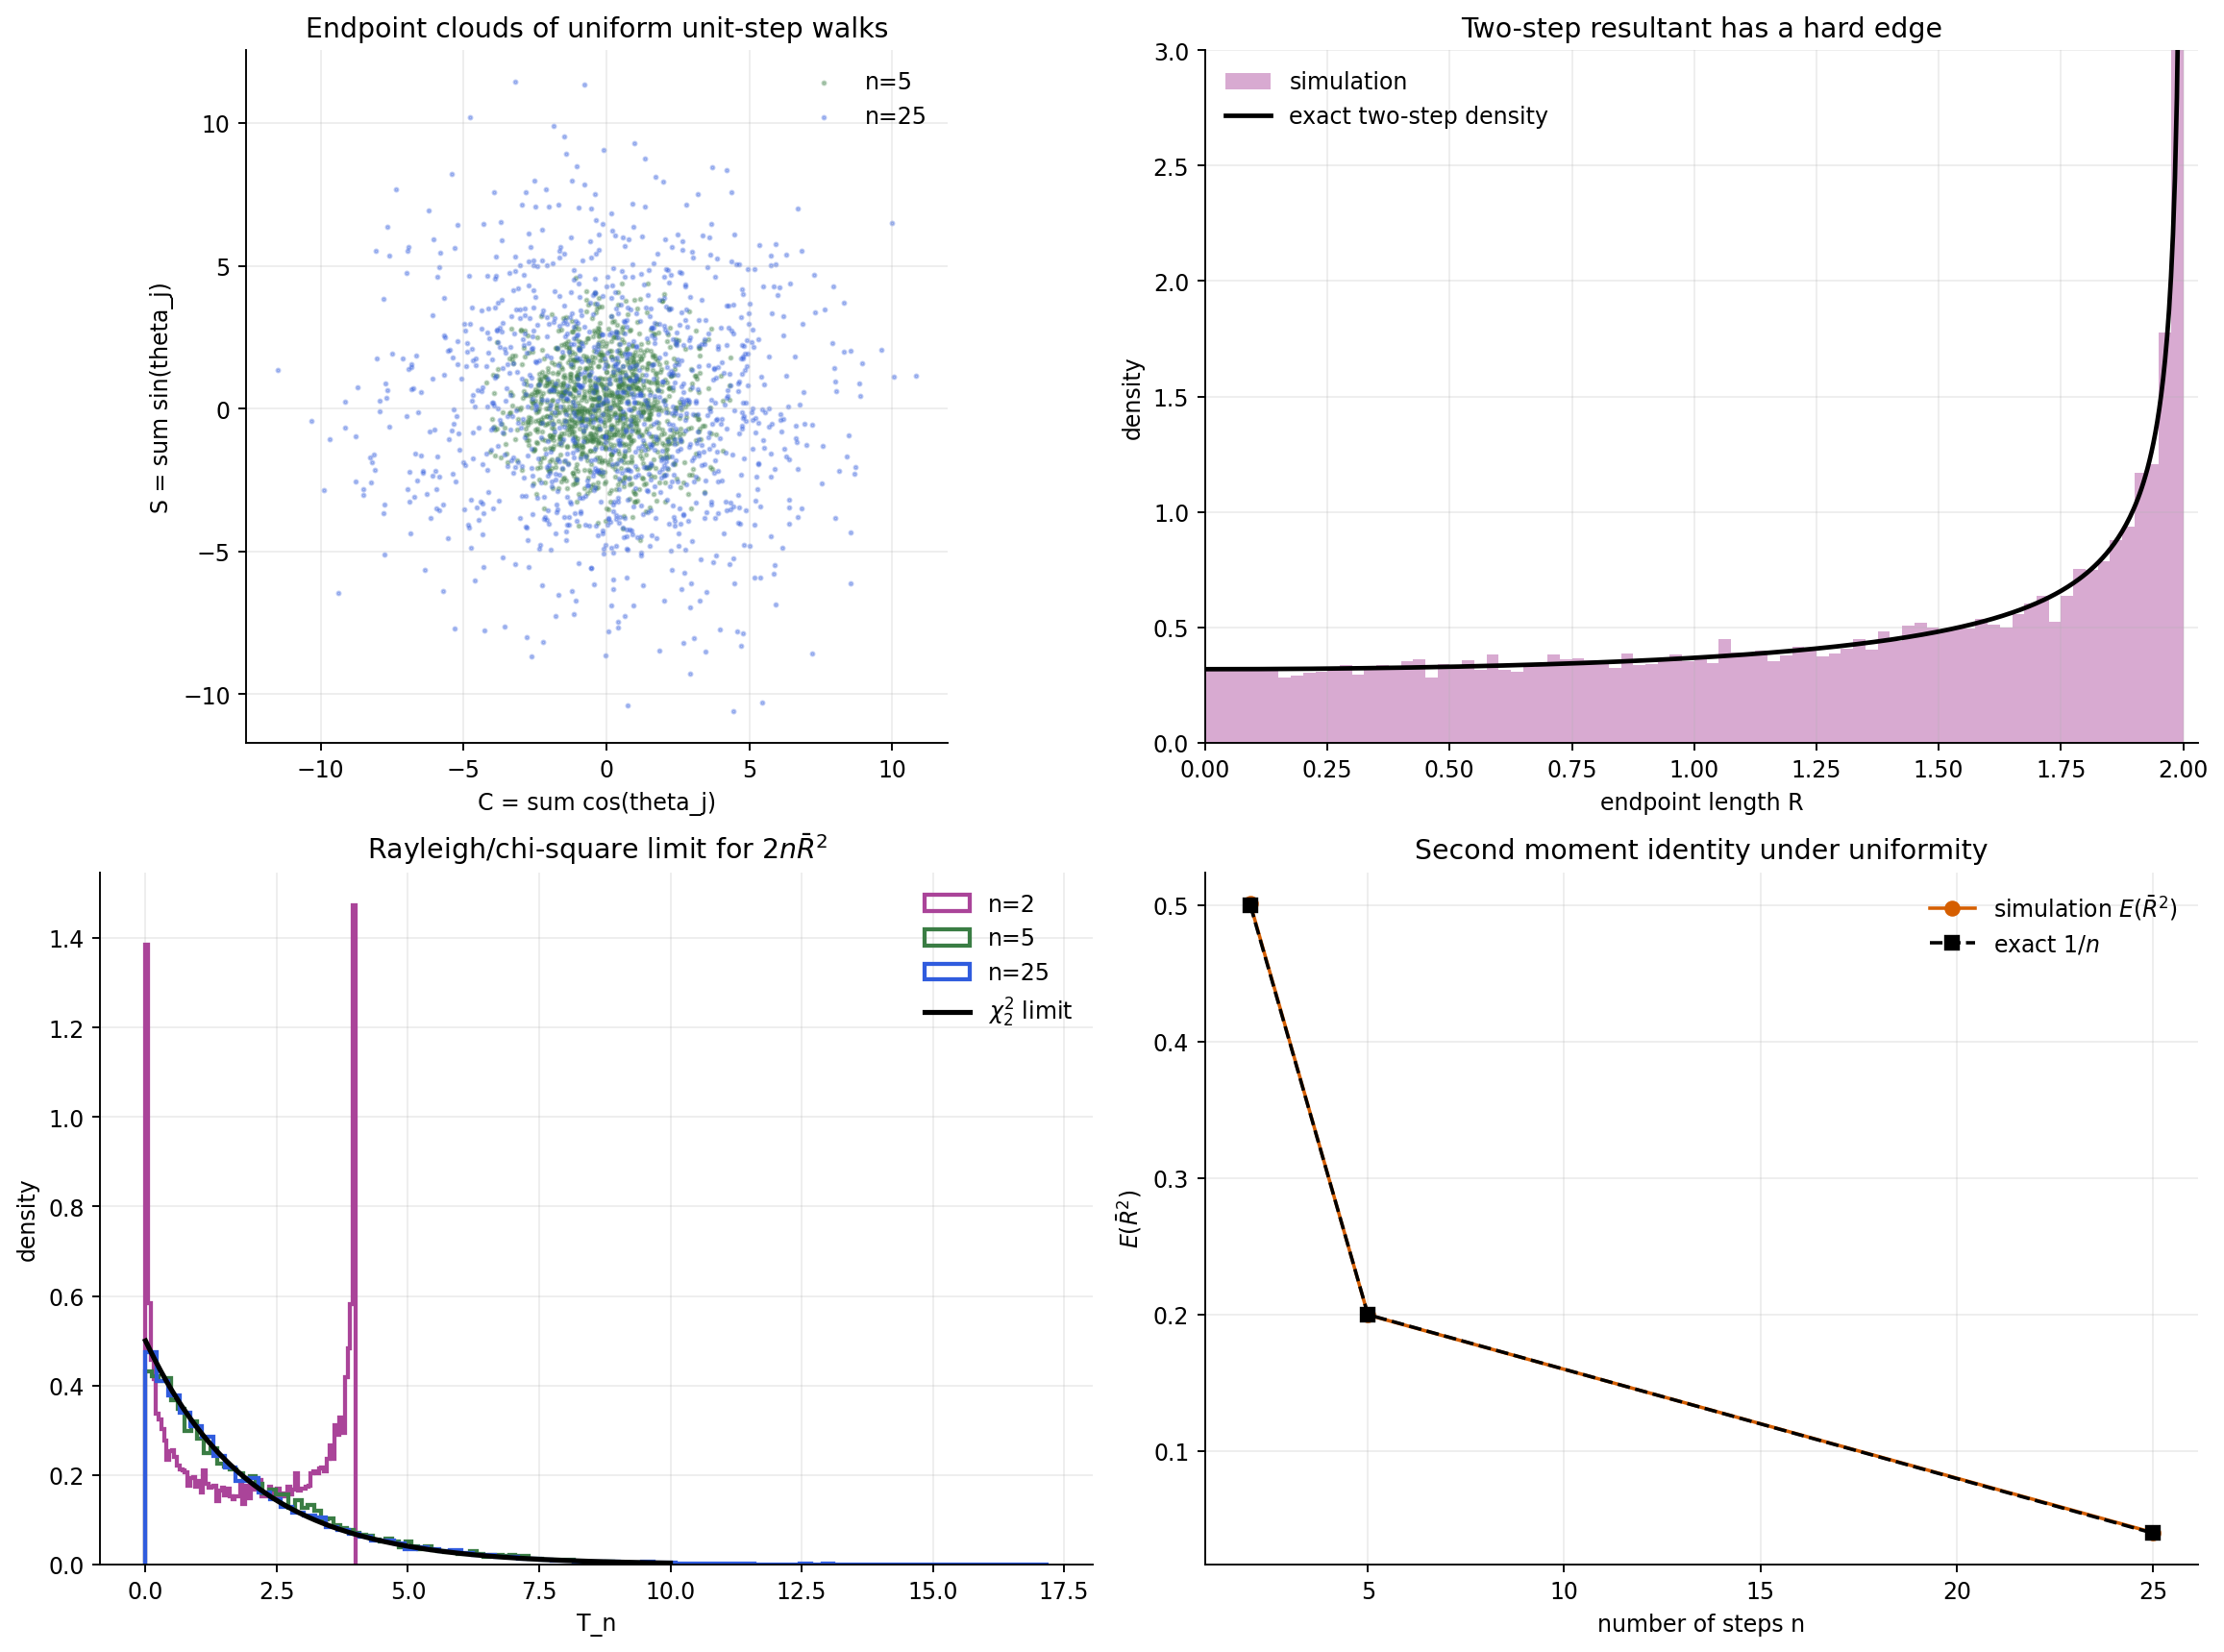

{'n_values': [2, 5, 25],
 'reps_per_n': 18000,
 'mean_rbar_squared': {'2': 0.5009501432349392,
  '5': 0.19979781723292575,
  '25': 0.04045565899512656},
 'target_rbar_squared': {'2': 0.5, '5': 0.2, '25': 0.04},
 'max_abs_mean_rbar_squared_error': 0.0009501432349392491,
 'ks_distance_2n_rbar_squared_to_chi2_2': {'2': 0.13533528472537737,
  '5': 0.02804945607216347,
  '25': 0.008961894960720307},
 'endpoint_sum_identity_max_error': 0.0}

In [4]:
def simulate_uniform_walk(n, reps):
    theta = rng.uniform(-np.pi, np.pi, size=(reps, n))
    C = np.cos(theta).sum(axis=1)
    S = np.sin(theta).sum(axis=1)
    R = np.hypot(C, S)
    Rbar = R / n
    return C, S, R, Rbar

walk_ns = [2, 5, 25]
walk_reps = 18000
walk_data = {n: simulate_uniform_walk(n, walk_reps) for n in walk_ns}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 10), constrained_layout=True)

for n, marker, color in [(5, ".", "#3A7D44"), (25, ".", "#305CDE")]:
    C, S, R, Rbar = walk_data[n]
    idx = rng.choice(walk_reps, size=1200, replace=False)
    axes[0, 0].scatter(C[idx], S[idx], s=9, alpha=0.32, label=f"n={n}", color=color, marker=marker)
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].set_title("Endpoint clouds of uniform unit-step walks")
axes[0, 0].set_xlabel("C = sum cos(theta_j)")
axes[0, 0].set_ylabel("S = sum sin(theta_j)")
axes[0, 0].legend(frameon=False)

r = np.linspace(0.001, 1.999, 500)
exact_two_step = 2 / (np.pi * np.sqrt(4 - r ** 2))
axes[0, 1].hist(walk_data[2][2], bins=80, density=True, alpha=0.45, color="#AA4499", label="simulation")
axes[0, 1].plot(r, exact_two_step, color="black", lw=2, label=r"exact two-step density")
axes[0, 1].set_xlim(0, 2.03)
axes[0, 1].set_ylim(0, 3.0)
axes[0, 1].set_title("Two-step resultant has a hard edge")
axes[0, 1].set_xlabel("endpoint length R")
axes[0, 1].set_ylabel("density")
axes[0, 1].legend(frameon=False)

x = np.linspace(0, 10, 500)
for n, color in zip(walk_ns, ["#AA4499", "#3A7D44", "#305CDE"]):
    T = 2 * n * walk_data[n][3] ** 2
    axes[1, 0].hist(T, bins=80, density=True, histtype="step", lw=1.8, color=color, label=f"n={n}")
axes[1, 0].plot(x, stats.chi2.pdf(x, df=2), color="black", lw=2.2, label=r"$\chi^2_2$ limit")
axes[1, 0].set_title(r"Rayleigh/chi-square limit for $2n\bar R^2$")
axes[1, 0].set_xlabel("T_n")
axes[1, 0].set_ylabel("density")
axes[1, 0].legend(frameon=False)

mean_rbar2 = []
ks_t = []
for n in walk_ns:
    Rbar = walk_data[n][3]
    T = 2 * n * Rbar ** 2
    mean_rbar2.append(np.mean(Rbar ** 2))
    ks_t.append(ks_distance(T, stats.chi2(df=2)))
axes[1, 1].plot(walk_ns, mean_rbar2, "o-", color="#D55E00", label=r"simulation $E(\bar R^2)$")
axes[1, 1].plot(walk_ns, [1 / n for n in walk_ns], "s--", color="black", label=r"exact $1/n$")
axes[1, 1].set_title("Second moment identity under uniformity")
axes[1, 1].set_xlabel("number of steps n")
axes[1, 1].set_ylabel(r"$E(\bar R^2)$")
axes[1, 1].legend(frameon=False)

walk_path = save_matplotlib(fig, TOPIC, "random-walks", "uniform-random-walk-resultants.png", dpi=170)
plt.close(fig)
all_artifacts.append(walk_path)
display_artifact(walk_path, width=980)

walk_checks = {
    "n_values": walk_ns,
    "reps_per_n": walk_reps,
    "mean_rbar_squared": {str(n): float(v) for n, v in zip(walk_ns, mean_rbar2)},
    "target_rbar_squared": {str(n): float(1 / n) for n in walk_ns},
    "max_abs_mean_rbar_squared_error": float(max(abs(v - 1 / n) for n, v in zip(walk_ns, mean_rbar2))),
    "ks_distance_2n_rbar_squared_to_chi2_2": {str(n): float(v) for n, v in zip(walk_ns, ks_t)},
    "endpoint_sum_identity_max_error": float(max(
        np.max(np.abs(np.hypot(data[0], data[1]) - data[2])) for data in walk_data.values()
    )),
}
chapter_checks["uniform_random_walks"] = walk_checks
walk_json_path = save_json(walk_checks, TOPIC, "checks", "uniform-random-walk-resultants.json")
all_artifacts.append(walk_json_path)
walk_checks


## CLT and the Tangent Coordinate

The planar CLT applies to the vector average $(\bar C, \bar S)$. The mean direction is a nonlinear coordinate derived from that average, so its normal approximation needs a tangent map and it fails at zero resultant length.

For a von Mises distribution centered at $\mu$ with concentration $\kappa$, the population resultant length is $A(\kappa)=I_1(\kappa)/I_0(\kappa)$. After rotating the coordinate system so $\mu=0$, the single-observation covariance of $(\cos\Theta,\sin\Theta)$ is diagonal:

$$\operatorname{var}(\cos\Theta)=\frac{1+A_2(\kappa)}{2}-A(\kappa)^2, \quad
\operatorname{var}(\sin\Theta)=\frac{1-A_2(\kappa)}{2}.$$

The tangent approximation standardizes the sample mean direction by the variance $1/(\kappa A(\kappa))$ for $n^{1/2}(\hat\mu-\mu)$.


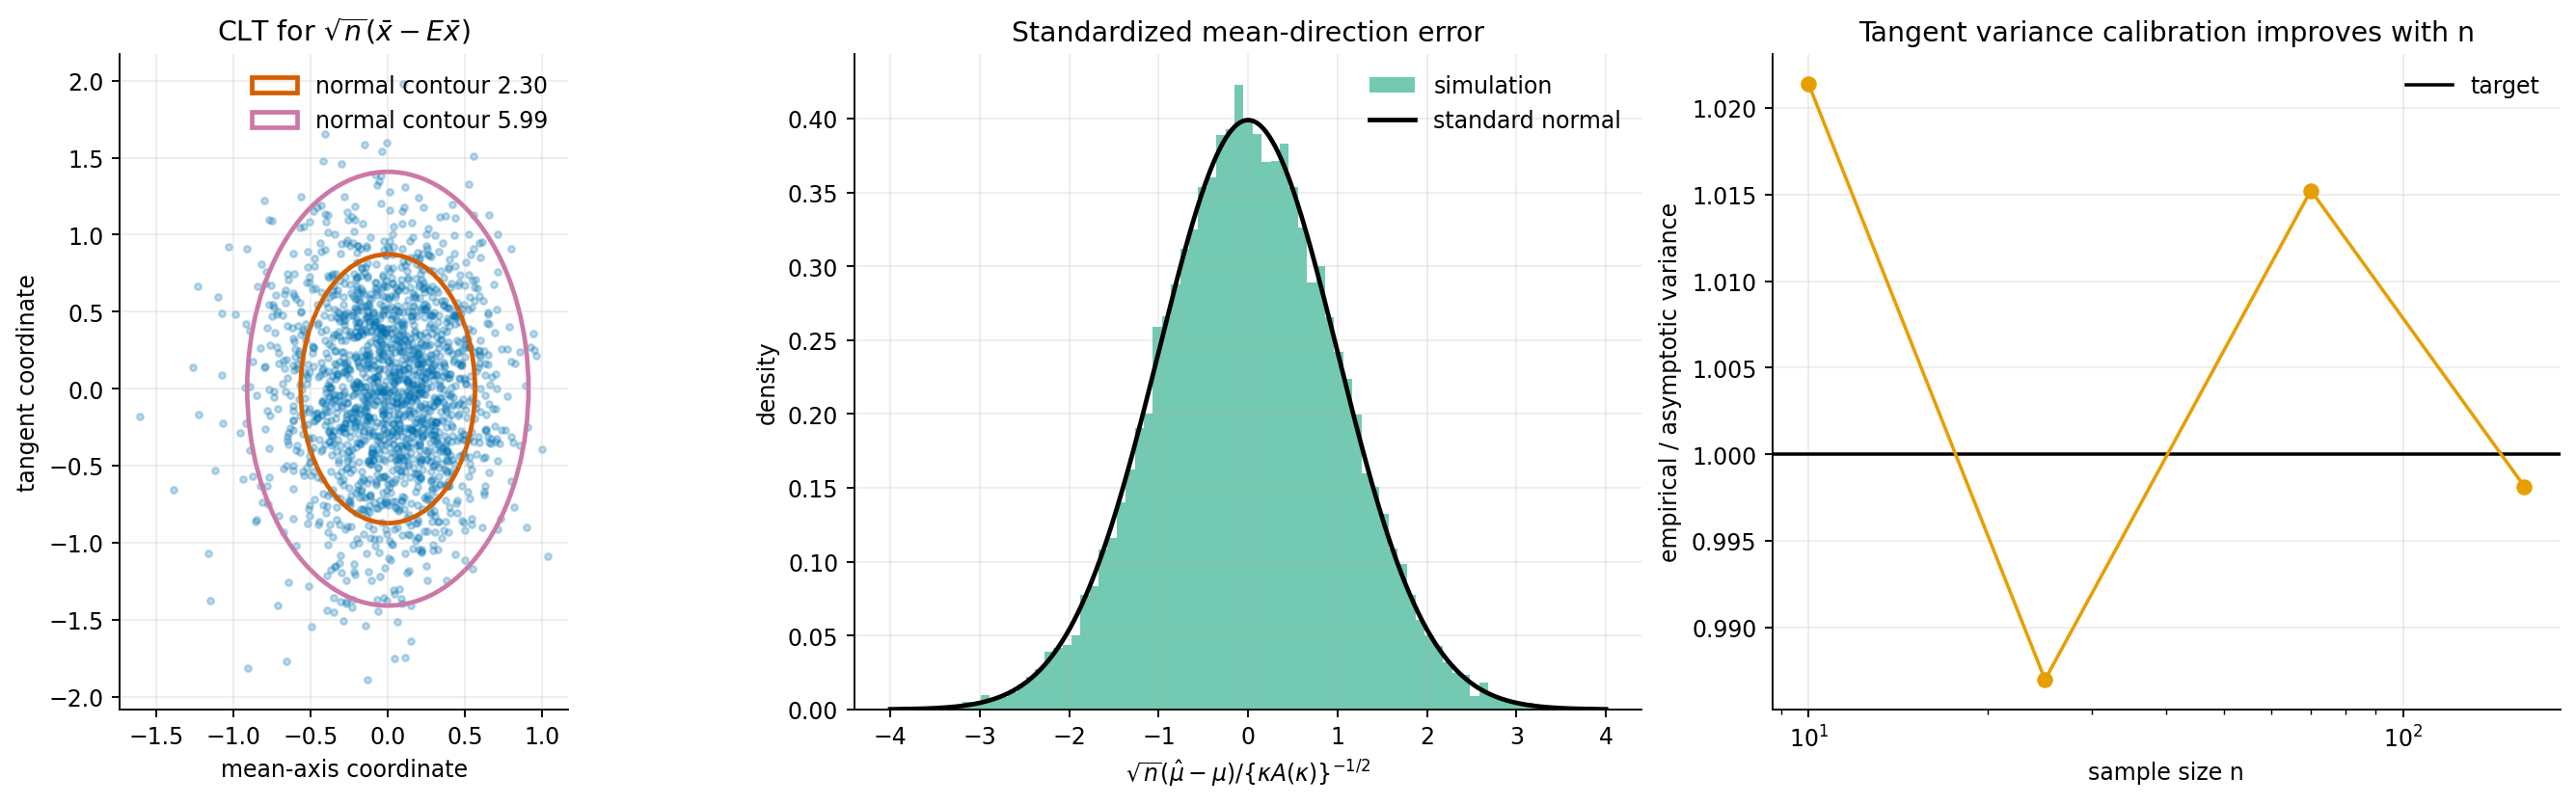

{'n': 70,
 'reps': 14000,
 'mu': 0.7,
 'kappa': 2.2,
 'A_kappa': 0.7280299131365096,
 'analytic_scaled_covariance': [[0.13904975778912376, 0.0],
  [0.0, 0.33092268778932254]],
 'empirical_scaled_covariance': [[0.13959330264754505, -0.003613168952187596],
  [-0.003613168952187596, 0.3297990037987074]],
 'covariance_relative_frobenius_error': 0.014654005478571947,
 'standardized_angle_mean': 0.005705473762063488,
 'standardized_angle_variance': 0.9995534446210472,
 'standardized_angle_ks_to_normal': 0.004924914108806799,
 'variance_ratio_by_n': {'10': 1.0213887990328074,
  '25': 0.9869912305729732,
  '70': 1.0152337510602636,
  '160': 0.9981488101605022}}

In [5]:
clt_reps = 14000
clt_n = 70
clt_mu = 0.7
clt_kappa = 2.2
samples = rng.vonmises(mu=clt_mu, kappa=clt_kappa, size=(clt_reps, clt_n))
Cbar, Sbar, Rbar, muhat = resultant(samples, axis=1)

# Rotate sample mean vectors into coordinates with the population mean direction on the x-axis.
Xrot = Cbar * np.cos(clt_mu) + Sbar * np.sin(clt_mu)
Yrot = -Cbar * np.sin(clt_mu) + Sbar * np.cos(clt_mu)
A = A1(clt_kappa)
A2 = Ap(2, clt_kappa)
Sigma_single = np.diag([(1 + A2) / 2 - A ** 2, (1 - A2) / 2])
scaled = np.column_stack([np.sqrt(clt_n) * (Xrot - A), np.sqrt(clt_n) * Yrot])
emp_cov = np.cov(scaled, rowvar=False)

angle_error = wrap_pi(muhat - clt_mu)
tangent_sd = math.sqrt(1 / (clt_kappa * A))
z_angle = np.sqrt(clt_n) * angle_error / tangent_sd

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
idx = rng.choice(clt_reps, size=1800, replace=False)
axes[0].scatter(scaled[idx, 0], scaled[idx, 1], s=8, alpha=0.25, color="#0072B2")
for level, color in [(2.30, "#D55E00"), (5.99, "#CC79A7")]:
    width = 2 * math.sqrt(level * Sigma_single[0, 0])
    height = 2 * math.sqrt(level * Sigma_single[1, 1])
    axes[0].add_patch(Ellipse((0, 0), width, height, fill=False, lw=2, color=color, label=f"normal contour {level:.2f}"))
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title(r"CLT for $\sqrt{n}(\bar x-E\bar x)$")
axes[0].set_xlabel("mean-axis coordinate")
axes[0].set_ylabel("tangent coordinate")
axes[0].legend(frameon=False, loc="upper right")

bins = np.linspace(-4, 4, 80)
axes[1].hist(z_angle, bins=bins, density=True, alpha=0.55, color="#009E73", label="simulation")
z = np.linspace(-4, 4, 500)
axes[1].plot(z, stats.norm.pdf(z), color="black", lw=2, label="standard normal")
axes[1].set_title("Standardized mean-direction error")
axes[1].set_xlabel(r"$\sqrt{n}(\hat\mu-\mu) / \{\kappa A(\kappa)\}^{-1/2}$")
axes[1].set_ylabel("density")
axes[1].legend(frameon=False)

n_grid = [10, 25, 70, 160]
var_ratios = []
for n in n_grid:
    s = rng.vonmises(mu=clt_mu, kappa=clt_kappa, size=(9000, n))
    _, _, _, mh = resultant(s, axis=1)
    ze = np.sqrt(n) * wrap_pi(mh - clt_mu)
    var_ratios.append(np.var(ze, ddof=1) / (1 / (clt_kappa * A)))
axes[2].axhline(1, color="black", lw=1.5, label="target")
axes[2].plot(n_grid, var_ratios, "o-", color="#E69F00")
axes[2].set_xscale("log")
axes[2].set_title("Tangent variance calibration improves with n")
axes[2].set_xlabel("sample size n")
axes[2].set_ylabel("empirical / asymptotic variance")
axes[2].legend(frameon=False)

clt_path = save_matplotlib(fig, TOPIC, "clt", "clt-tangent-coordinate-approximation.png", dpi=170)
plt.close(fig)
all_artifacts.append(clt_path)
display_artifact(clt_path, width=1060)

clt_checks = {
    "n": clt_n,
    "reps": clt_reps,
    "mu": clt_mu,
    "kappa": clt_kappa,
    "A_kappa": float(A),
    "analytic_scaled_covariance": Sigma_single.tolist(),
    "empirical_scaled_covariance": emp_cov.tolist(),
    "covariance_relative_frobenius_error": float(np.linalg.norm(emp_cov - Sigma_single) / np.linalg.norm(Sigma_single)),
    "standardized_angle_mean": float(np.mean(z_angle)),
    "standardized_angle_variance": float(np.var(z_angle, ddof=1)),
    "standardized_angle_ks_to_normal": ks_distance(z_angle, stats.norm()),
    "variance_ratio_by_n": {str(n): float(v) for n, v in zip(n_grid, var_ratios)},
}
chapter_checks["clt_tangent"] = clt_checks
clt_json_path = save_json(clt_checks, TOPIC, "checks", "clt-tangent-coordinate-approximation.json")
all_artifacts.append(clt_json_path)
clt_checks


## High-Concentration Normal Approximations

When $\kappa$ is large, a von Mises law is concentrated near its mean direction. The local coordinate $u=\sqrt{\kappa}(\Theta-\mu)$ behaves like a standard normal variable, and quadratic circular quantities behave like chi-square variables.

For samples centered at the true mean direction, write

$$\bar C = n^{-1}\sum_j \cos(\Theta_j-\mu), \quad
\bar R = \left|n^{-1}\sum_j (\cos\Theta_j,\sin\Theta_j)\right|.$$

A Bartlett-style correction uses $\gamma^{-1}=\kappa^{-1}+3/(8\kappa^2)$. Then the decomposition

$$2n\gamma(1-\bar C)=2n\gamma(1-\bar R)+2n\gamma(\bar R-\bar C)$$

separates scatter around the fitted mean direction from movement of the fitted mean direction itself. The first piece is approximately chi-square with $n-1$ degrees of freedom and the second with 1 degree of freedom.


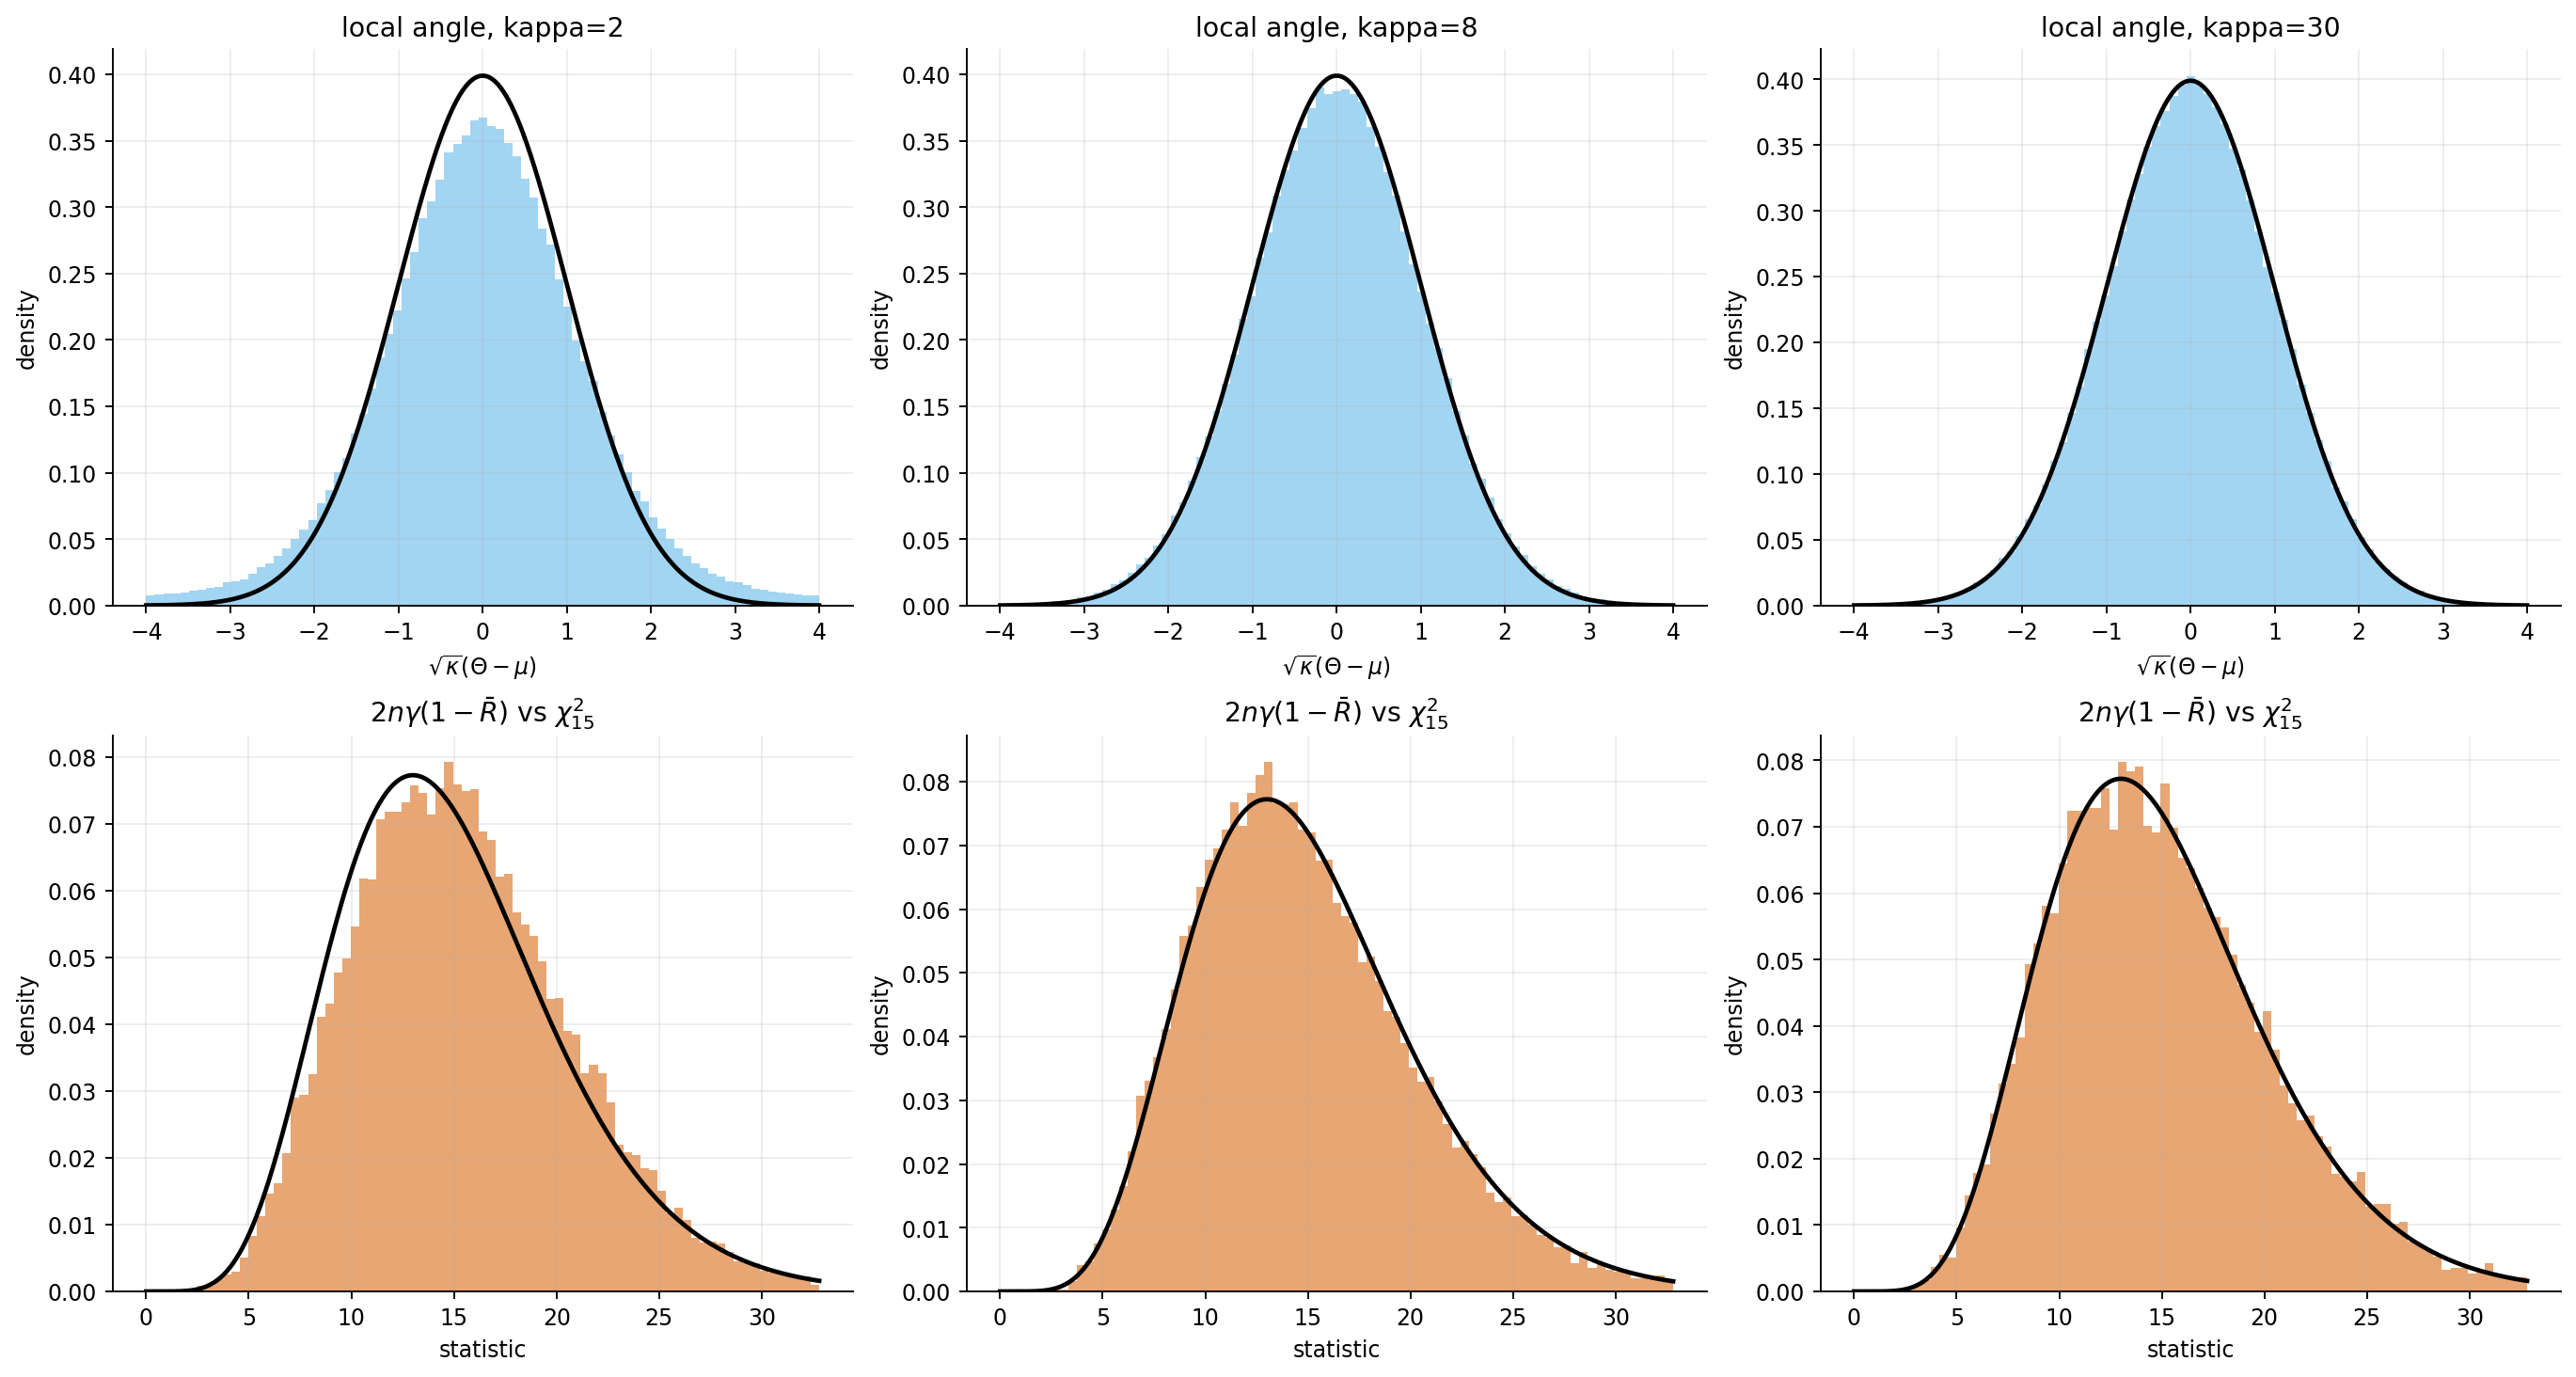

{'n': 16,
 'reps': 26000,
 'kappas': [2.0, 8.0, 30.0],
 'scenario_checks': {'2.0': {'gamma': 1.6842105263157894,
   'angle_scaled_mean': 0.0010292010061880696,
   'angle_scaled_variance': 1.5317046413750235,
   'angle_ks_to_normal': 0.03250198259041748,
   'total_ks_to_chi2_n': 0.038918766180022935,
   'concentration_ks_to_chi2_n_minus_1': 0.05185435066441274,
   'direction_ks_to_chi2_1': 0.04305925085168105,
   'max_abs_additive_residual': 9.325873406851315e-15},
  '8.0': {'gamma': 7.641791044776119,
   'angle_scaled_mean': 0.0004317375027426961,
   'angle_scaled_variance': 1.071730068376077,
   'angle_ks_to_normal': 0.006450797574356515,
   'total_ks_to_chi2_n': 0.016636311375948398,
   'concentration_ks_to_chi2_n_minus_1': 0.014395281755549272,
   'direction_ks_to_chi2_1': 0.011157455965487673,
   'max_abs_additive_residual': 6.467049118441537e-15},
  '30.0': {'gamma': 29.629629629629626,
   'angle_scaled_mean': 0.001617189426648189,
   'angle_scaled_variance': 1.021835531213858,
  

In [6]:
def high_concentration_stats(kappa, n, reps):
    theta = rng.vonmises(mu=0.0, kappa=kappa, size=(reps, n))
    Cbar = np.cos(theta).mean(axis=1)
    Sbar = np.sin(theta).mean(axis=1)
    Rbar = np.hypot(Cbar, Sbar)
    gamma = 1.0 / (1.0 / kappa + 3.0 / (8.0 * kappa ** 2))
    total = 2 * n * gamma * (1 - Cbar)
    concentration = 2 * n * gamma * (1 - Rbar)
    direction = 2 * n * gamma * np.maximum(Rbar - Cbar, 0)
    additive_residual = total - concentration - direction
    return {
        "theta": theta,
        "gamma": gamma,
        "total": total,
        "concentration": concentration,
        "direction": direction,
        "additive_residual": additive_residual,
    }

hc_n = 16
hc_reps = 26000
hc_kappas = [2.0, 8.0, 30.0]
hc = {k: high_concentration_stats(k, hc_n, hc_reps) for k in hc_kappas}

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), constrained_layout=True)
for col, kappa in enumerate(hc_kappas):
    z = np.sqrt(kappa) * wrap_pi(hc[kappa]["theta"].ravel())
    axes[0, col].hist(z, bins=np.linspace(-4, 4, 80), density=True, alpha=0.55, color="#56B4E9")
    x = np.linspace(-4, 4, 500)
    axes[0, col].plot(x, stats.norm.pdf(x), color="black", lw=2)
    axes[0, col].set_title(f"local angle, kappa={kappa:g}")
    axes[0, col].set_xlabel(r"$\sqrt{\kappa}(\Theta-\mu)$")
    axes[0, col].set_ylabel("density")

    t = hc[kappa]["concentration"]
    upper = stats.chi2.ppf(0.995, df=hc_n - 1)
    bins = np.linspace(0, upper, 80)
    axes[1, col].hist(t, bins=bins, density=True, alpha=0.55, color="#D55E00")
    xx = np.linspace(0, upper, 500)
    axes[1, col].plot(xx, stats.chi2.pdf(xx, df=hc_n - 1), color="black", lw=2)
    axes[1, col].set_title(rf"$2n\gamma(1-\bar R)$ vs $\chi^2_{{{hc_n-1}}}$")
    axes[1, col].set_xlabel("statistic")
    axes[1, col].set_ylabel("density")

hc_checks = {}
for kappa in hc_kappas:
    rec = hc[kappa]
    hc_checks[str(kappa)] = {
        "gamma": float(rec["gamma"]),
        "angle_scaled_mean": float(np.mean(np.sqrt(kappa) * wrap_pi(rec["theta"].ravel()))),
        "angle_scaled_variance": float(np.var(np.sqrt(kappa) * wrap_pi(rec["theta"].ravel()), ddof=1)),
        "angle_ks_to_normal": ks_distance(np.sqrt(kappa) * wrap_pi(rec["theta"].ravel()), stats.norm()),
        "total_ks_to_chi2_n": ks_distance(rec["total"], stats.chi2(df=hc_n)),
        "concentration_ks_to_chi2_n_minus_1": ks_distance(rec["concentration"], stats.chi2(df=hc_n - 1)),
        "direction_ks_to_chi2_1": ks_distance(rec["direction"], stats.chi2(df=1)),
        "max_abs_additive_residual": float(np.max(np.abs(rec["additive_residual"]))),
    }

hc_path = save_matplotlib(fig, TOPIC, "high-concentration", "high-concentration-normal-approximations.png", dpi=170)
plt.close(fig)
all_artifacts.append(hc_path)
display_artifact(hc_path, width=1060)

chapter_checks["high_concentration"] = {
    "n": hc_n,
    "reps": hc_reps,
    "kappas": hc_kappas,
    "scenario_checks": hc_checks,
}
hc_json_path = save_json(chapter_checks["high_concentration"], TOPIC, "checks", "high-concentration-normal-approximations.json")
all_artifacts.append(hc_json_path)
chapter_checks["high_concentration"]


## Applied Lab: Choose an Approximation Regime

The applied problem is not to memorize which approximation exists. It is to decide which approximation is defensible for a sample size and concentration before using it in an inference procedure.

Use this lab as a calibration workflow. The first curve tracks the uniform random-walk statistic $2n\bar R^2$ against its chi-square limit as $n$ grows. The second curve tracks the high-concentration statistic $2n\gamma(1-\bar R)$ against its chi-square target as $\kappa$ grows. Smaller KS distance means the simulated distribution is closer to the reference distribution.


In [7]:
lab_reps = 16000
uniform_ns = [4, 8, 16, 32, 80, 160]
uniform_lab = []
for n in uniform_ns:
    _, _, _, Rbar = simulate_uniform_walk(n, lab_reps)
    T = 2 * n * Rbar ** 2
    uniform_lab.append({
        "n": n,
        "ks_to_chi2_2": ks_distance(T, stats.chi2(df=2)),
        "mean_T": float(np.mean(T)),
        "target_mean": 2.0,
    })

lab_n = 16
kappa_grid = [1.5, 2.0, 4.0, 8.0, 16.0, 32.0]
concentration_lab = []
for kappa in kappa_grid:
    rec = high_concentration_stats(kappa, lab_n, lab_reps)
    concentration_lab.append({
        "kappa": kappa,
        "gamma": float(rec["gamma"]),
        "ks_to_chi2_n_minus_1": ks_distance(rec["concentration"], stats.chi2(df=lab_n - 1)),
        "mean_statistic": float(np.mean(rec["concentration"])),
        "target_mean": float(lab_n - 1),
    })

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Uniform resultant: 2 n Rbar^2 -> chi-square(2)",
        "High concentration: 2 n gamma (1 - Rbar) -> chi-square(n-1)",
    ),
)
fig.add_trace(
    go.Scatter(
        x=[d["n"] for d in uniform_lab],
        y=[d["ks_to_chi2_2"] for d in uniform_lab],
        mode="lines+markers",
        name="uniform walk KS",
        line=dict(color="#305CDE", width=3),
        marker=dict(size=8),
        hovertemplate="n=%{x}<br>KS=%{y:.4f}<extra></extra>",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=[d["kappa"] for d in concentration_lab],
        y=[d["ks_to_chi2_n_minus_1"] for d in concentration_lab],
        mode="lines+markers",
        name="high concentration KS",
        line=dict(color="#D55E00", width=3),
        marker=dict(size=8),
        hovertemplate="kappa=%{x}<br>KS=%{y:.4f}<extra></extra>",
    ),
    row=1,
    col=2,
)
fig.update_xaxes(type="log", title_text="sample size n", row=1, col=1)
fig.update_xaxes(type="log", title_text="concentration kappa", row=1, col=2)
fig.update_yaxes(title_text="KS distance to reference", rangemode="tozero", row=1, col=1)
fig.update_yaxes(title_text="KS distance to reference", rangemode="tozero", row=1, col=2)
fig.update_layout(
    template="plotly_white",
    width=980,
    height=460,
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="left", x=0.0),
    margin=dict(l=45, r=35, t=80, b=45),
)

lab_html_path = save_plotly_html(fig, TOPIC, "interactive", "approximation-regime-lab.html", include_plotlyjs=True)
all_artifacts.append(lab_html_path)
display_artifact(lab_html_path, width="100%", height=520)

lab_checks = {
    "uniform_reps": lab_reps,
    "uniform_resultant": uniform_lab,
    "high_concentration_reps": lab_reps,
    "high_concentration_n": lab_n,
    "high_concentration_resultant": concentration_lab,
}
chapter_checks["applied_lab"] = lab_checks
lab_json_path = save_json(lab_checks, TOPIC, "checks", "approximation-regime-lab.json")
all_artifacts.append(lab_json_path)
lab_checks


{'uniform_reps': 16000,
 'uniform_resultant': [{'n': 4,
   'ks_to_chi2_2': 0.04859693492924372,
   'mean_T': 2.011040546451023,
   'target_mean': 2.0},
  {'n': 8,
   'ks_to_chi2_2': 0.021097972941031107,
   'mean_T': 2.020024787589504,
   'target_mean': 2.0},
  {'n': 16,
   'ks_to_chi2_2': 0.015912903686689933,
   'mean_T': 2.0263577573845706,
   'target_mean': 2.0},
  {'n': 32,
   'ks_to_chi2_2': 0.004367481539413909,
   'mean_T': 1.988393236377894,
   'target_mean': 2.0},
  {'n': 80,
   'ks_to_chi2_2': 0.0073333668850524,
   'mean_T': 1.9978374146685596,
   'target_mean': 2.0},
  {'n': 160,
   'ks_to_chi2_2': 0.006236276608229507,
   'mean_T': 1.9925564035877055,
   'target_mean': 2.0}],
 'high_concentration_reps': 16000,
 'high_concentration_n': 16,
 'high_concentration_resultant': [{'kappa': 1.5,
   'gamma': 1.2000000000000002,
   'ks_to_chi2_n_minus_1': 0.046769006017688075,
   'mean_statistic': 14.603710983326335,
   'target_mean': 15.0},
  {'kappa': 2.0,
   'gamma': 1.6842105263

## Sanity Checks

The checks below are intentionally a mix of algebraic identities, simulation tolerances, artifact integrity, and approximation diagnostics. They do not prove the theorems, but they make the notebook falsifiable: a broken circular convention, stale artifact, or failed approximation should be caught here rather than hidden in a figure.


In [8]:
artifact_records = assert_artifacts(all_artifacts, min_bytes=100)

# Characteristic-function identities.
assert fingerprint_checks["max_conjugate_symmetry_error"] < 1e-12
assert fingerprint_checks["uniform_nonzero_harmonic_max_abs"] == 0.0
assert set(abs(p) for p in fingerprint_checks["lattice_visible_harmonics"]) == {5, 10, 15}

# Random-walk identities and asymptotics.
assert walk_checks["endpoint_sum_identity_max_error"] < 1e-12
assert walk_checks["max_abs_mean_rbar_squared_error"] < 0.012
assert walk_checks["ks_distance_2n_rbar_squared_to_chi2_2"]["25"] < 0.035

# Tangent-coordinate CLT diagnostics.
assert clt_checks["covariance_relative_frobenius_error"] < 0.08
assert abs(clt_checks["standardized_angle_mean"]) < 0.05
assert 0.90 < clt_checks["standardized_angle_variance"] < 1.10
assert clt_checks["standardized_angle_ks_to_normal"] < 0.025

# High-concentration diagnostics.
hc_scenarios = chapter_checks["high_concentration"]["scenario_checks"]
assert hc_scenarios["30.0"]["angle_ks_to_normal"] < hc_scenarios["2.0"]["angle_ks_to_normal"]
assert hc_scenarios["30.0"]["concentration_ks_to_chi2_n_minus_1"] < 0.06
assert max(v["max_abs_additive_residual"] for v in hc_scenarios.values()) < 1e-10

# Applied-lab convergence should improve at the large end of each regime.
uniform_lab_checks = chapter_checks["applied_lab"]["uniform_resultant"]
concentration_lab_checks = chapter_checks["applied_lab"]["high_concentration_resultant"]
assert uniform_lab_checks[-1]["ks_to_chi2_2"] < uniform_lab_checks[0]["ks_to_chi2_2"]
assert concentration_lab_checks[-1]["ks_to_chi2_n_minus_1"] < concentration_lab_checks[0]["ks_to_chi2_n_minus_1"]

final_sanity = {
    "source_span": SOURCE_SPAN,
    "artifact_records": artifact_records,
    "check_groups": sorted(chapter_checks),
    "fingerprint_max_conjugate_symmetry_error": fingerprint_checks["max_conjugate_symmetry_error"],
    "uniform_walk_max_abs_mean_rbar_squared_error": walk_checks["max_abs_mean_rbar_squared_error"],
    "clt_covariance_relative_frobenius_error": clt_checks["covariance_relative_frobenius_error"],
    "high_concentration_kappa_30_concentration_ks": hc_scenarios["30.0"]["concentration_ks_to_chi2_n_minus_1"],
    "applied_lab_uniform_first_last_ks": [uniform_lab_checks[0]["ks_to_chi2_2"], uniform_lab_checks[-1]["ks_to_chi2_2"]],
    "applied_lab_concentration_first_last_ks": [concentration_lab_checks[0]["ks_to_chi2_n_minus_1"], concentration_lab_checks[-1]["ks_to_chi2_n_minus_1"]],
}
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert_artifacts([final_path], min_bytes=100)
display_artifact(final_path)
final_sanity


{'source_span': {'printed_pages': '57-82', 'pdf_pages': '74-99'},
 'artifact_records': [{'path': 'artifacts/chapter-04/characteristic-functions/characteristic-function-fingerprints.png',
   'exists': True,
   'bytes': 119737},
  {'path': 'artifacts/chapter-04/checks/characteristic-function-fingerprints.json',
   'exists': True,
   'bytes': 365},
  {'path': 'artifacts/chapter-04/random-walks/uniform-random-walk-resultants.png',
   'exists': True,
   'bytes': 282095},
  {'path': 'artifacts/chapter-04/checks/uniform-random-walk-resultants.json',
   'exists': True,
   'bytes': 528},
  {'path': 'artifacts/chapter-04/clt/clt-tangent-coordinate-approximation.png',
   'exists': True,
   'bytes': 316630},
  {'path': 'artifacts/chapter-04/checks/clt-tangent-coordinate-approximation.json',
   'exists': True,
   'bytes': 818},
  {'path': 'artifacts/chapter-04/high-concentration/high-concentration-normal-approximations.png',
   'exists': True,
   'bytes': 226917},
  {'path': 'artifacts/chapter-04/c

## Takeaways

- A circular characteristic function is an integer harmonic fingerprint. Uniform, lattice, wrapped, and von Mises laws leave visibly different coefficient patterns.
- Resultant length is the radial part of a planar unit-step random walk. Under uniformity, the mean direction is rotationally uninformative, but $2n\bar R^2$ has a useful chi-square limit.
- The central limit theorem first applies to $(\bar C,\bar S)$. A mean-direction normal approximation is a tangent-coordinate approximation and needs nonzero population resultant length.
- High concentration turns circular deviations into local normal coordinates. The corrected statistics split total angular scatter into concentration and fitted-direction pieces, mirroring a normal sum-of-squares decomposition.
- The approximation regime is empirical as well as theoretical. Sample size, concentration, and the statistic being approximated all affect whether the reference distribution is accurate enough.
